# DASU-Net — Experiment Comparison

This notebook compares **Baseline (ViT + LinearDecoder)** vs **Improved (Swin + DualAttention + NonLinearDecoder)** architectures on the Samson dataset.

## Contents
1. Load experiment results
2. Metrics comparison table
3. Loss convergence curves
4. Endmember spectra comparison
5. Abundance map comparison

In [1]:
import sys, os
# Ensure project root is on path
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

from src.utils.plotters import (
    load_run, plot_loss_comparison, plot_endmembers_comparison,
    plot_abundances_comparison, plot_endmembers, plot_abundances,
    print_metrics_table,
)
from src.data import HyperspectralDataset

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Ready!')

Ready!


## 1. Load Experiment Results

Adjust the paths below to point to your actual run directories.

In [2]:
# ===== CONFIGURE THESE PATHS =====
# Find the latest ViT and Swin runs automatically
vit_runs = sorted(glob('runs/samson_vit_*'))
swin_runs = sorted(glob('runs/samson_swin_*'))

assert len(vit_runs) > 0, 'No ViT runs found! Train first with: python main.py --config configs/base.yaml'
assert len(swin_runs) > 0, 'No Swin runs found! Train first with: python main.py --config configs/base.yaml --override configs/exp_full.yaml'

# Take the latest run of each type
vit_dir = vit_runs[-1]
swin_dir = swin_runs[-1]

print(f'Baseline (ViT):  {vit_dir}')
print(f'Improved (Swin): {swin_dir}')

# Load results
run_vit = load_run(vit_dir)
run_swin = load_run(swin_dir)

runs = [run_vit, run_swin]
labels = ['Baseline (ViT+Linear)', 'Improved (Swin+DualAttn+NonLinear)']

print(f'\nBaseline epochs: {len(run_vit["losses"])}')
print(f'Improved epochs: {len(run_swin["losses"])}')

Baseline (ViT):  runs\samson_vit_20260512_030728
Improved (Swin): runs\samson_swin_20260512_025315

Baseline epochs: 200
Improved epochs: 200


## 2. Load Ground Truth Data

In [3]:
dataset = HyperspectralDataset('samson', data_dir='./data/raw', device='cpu')

E_gt = dataset.get_endmembers().numpy()           # (L, P)
A_gt = dataset.get_abundance_cube().cpu().numpy()  # (H, W, P)

ENDMEMBER_NAMES = ['Soil', 'Tree', 'Water']
print(f'GT Endmembers: {E_gt.shape}')
print(f'GT Abundances: {A_gt.shape}')

GT Endmembers: (156, 3)
GT Abundances: (95, 95, 3)


## 3. Metrics Comparison Table

In [4]:
# Summary table
print('\n=== Final Metrics ===')
print_metrics_table(runs, labels)

# Detailed per-endmember breakdown
for run, lbl in zip(runs, labels):
    print(f'\n--- {lbl} ---')
    for i, name in enumerate(ENDMEMBER_NAMES):
        print(f'  {name:8s}  RMSE={run["rmse_cls"][i]:.4f}  SAD={run["sad_cls"][i]:.4f}')


=== Final Metrics ===
-----------------------------------------------
Model                      Mean RMSE   Mean SAD
-----------------------------------------------
Baseline (ViT+Linear)         0.4982     0.3616
Improved (Swin+DualAttn+NonLinear)     0.1570     0.1938
-----------------------------------------------

--- Baseline (ViT+Linear) ---
  Soil      RMSE=0.6880  SAD=0.1921
  Tree      RMSE=0.1581  SAD=0.0990
  Water     RMSE=0.6487  SAD=0.7939

--- Improved (Swin+DualAttn+NonLinear) ---
  Soil      RMSE=0.1261  SAD=0.0125
  Tree      RMSE=0.2052  SAD=0.1197
  Water     RMSE=0.1397  SAD=0.4492


## 4. Loss Convergence Curves

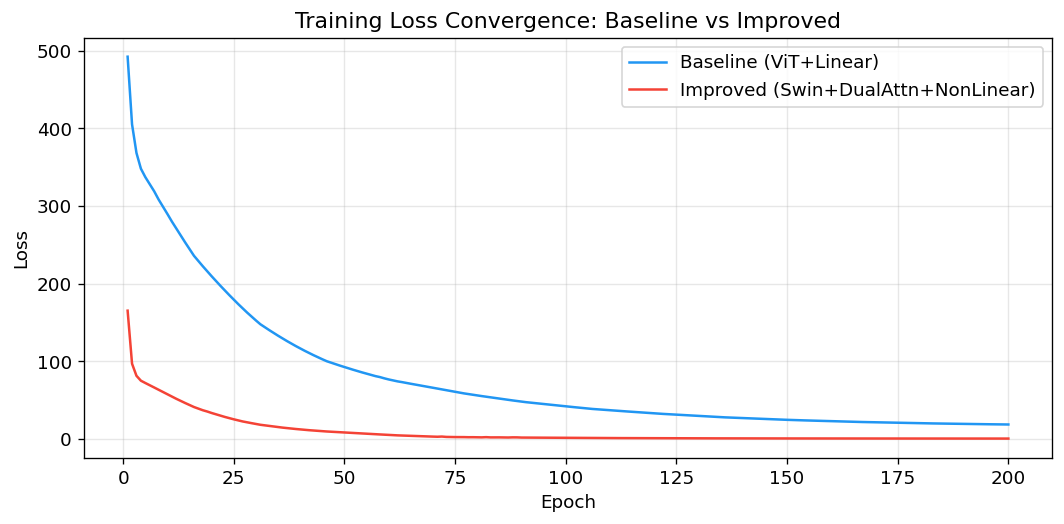

In [5]:
fig = plot_loss_comparison(
    runs, labels,
    title='Training Loss Convergence: Baseline vs Improved',
)
plt.show()

## 5. Endmember Spectra Comparison

Predicted endmember spectra overlaid with Ground Truth.

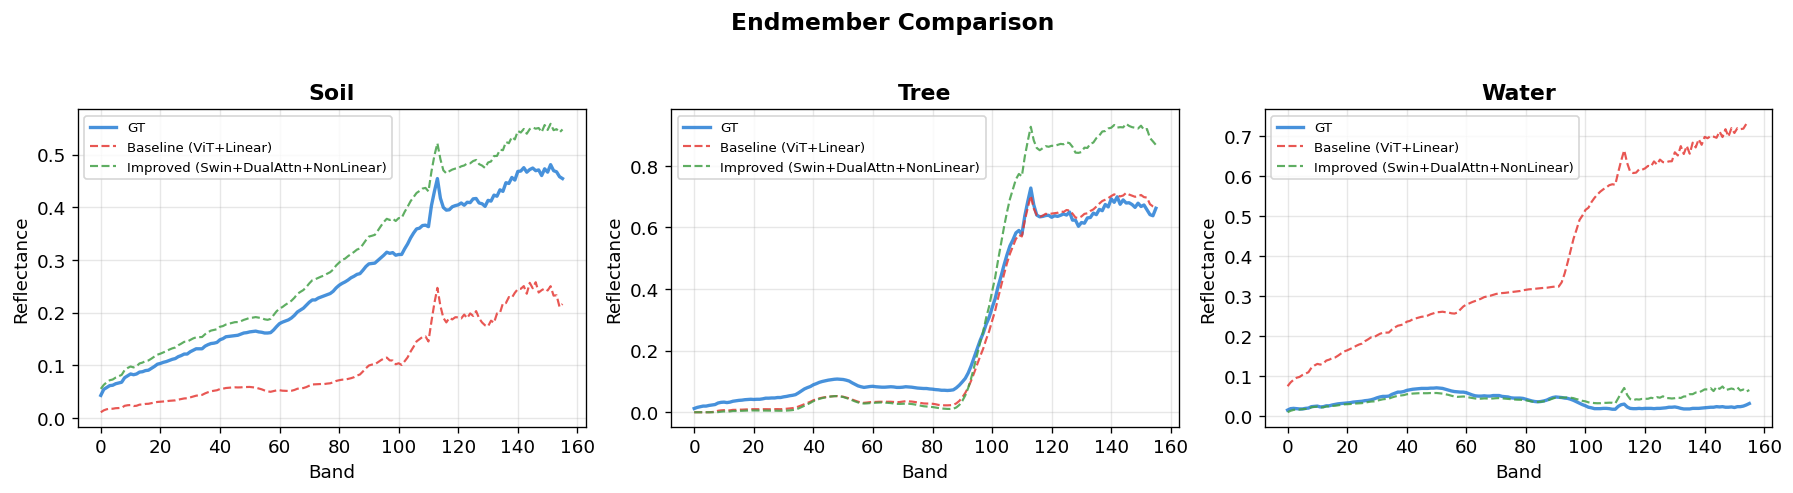

In [6]:
# Side-by-side: both models vs GT
fig = plot_endmembers_comparison(
    runs, labels, E_gt,
    endmember_names=ENDMEMBER_NAMES,
)
plt.show()

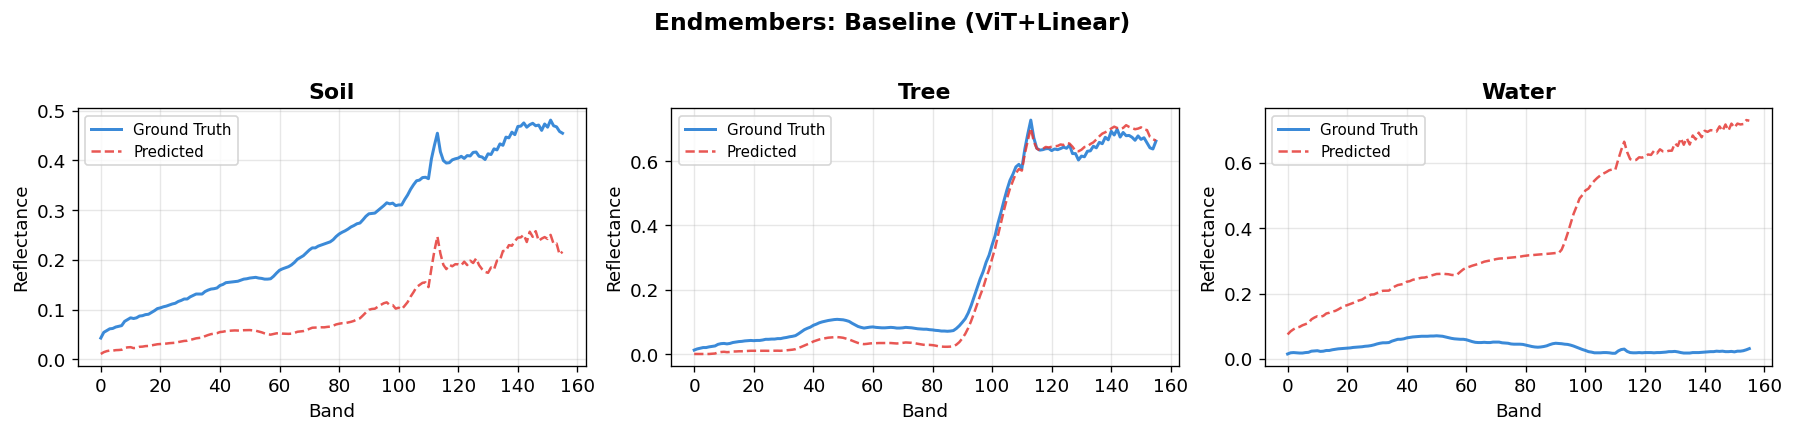

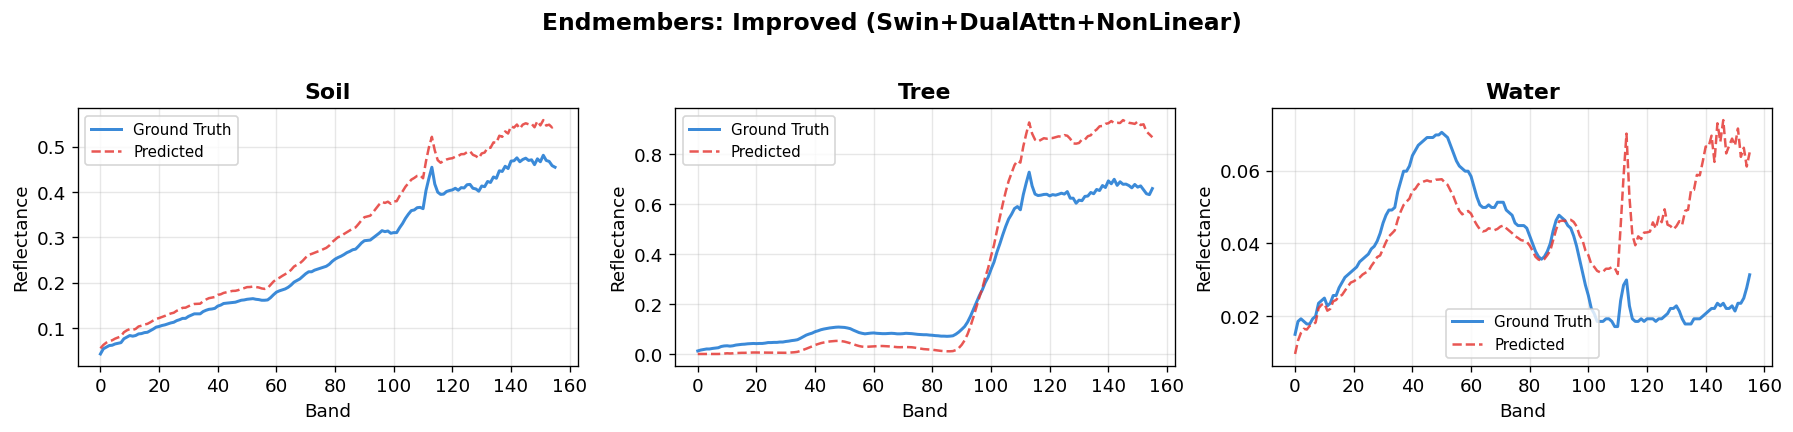

In [7]:
# Individual model endmember plots
for run, lbl in zip(runs, labels):
    fig = plot_endmembers(
        run['est_endmem'], E_gt,
        endmember_names=ENDMEMBER_NAMES,
        title=f'Endmembers: {lbl}',
    )
    plt.show()

## 6. Abundance Maps Comparison

Ground Truth (top) vs model predictions (bottom rows).

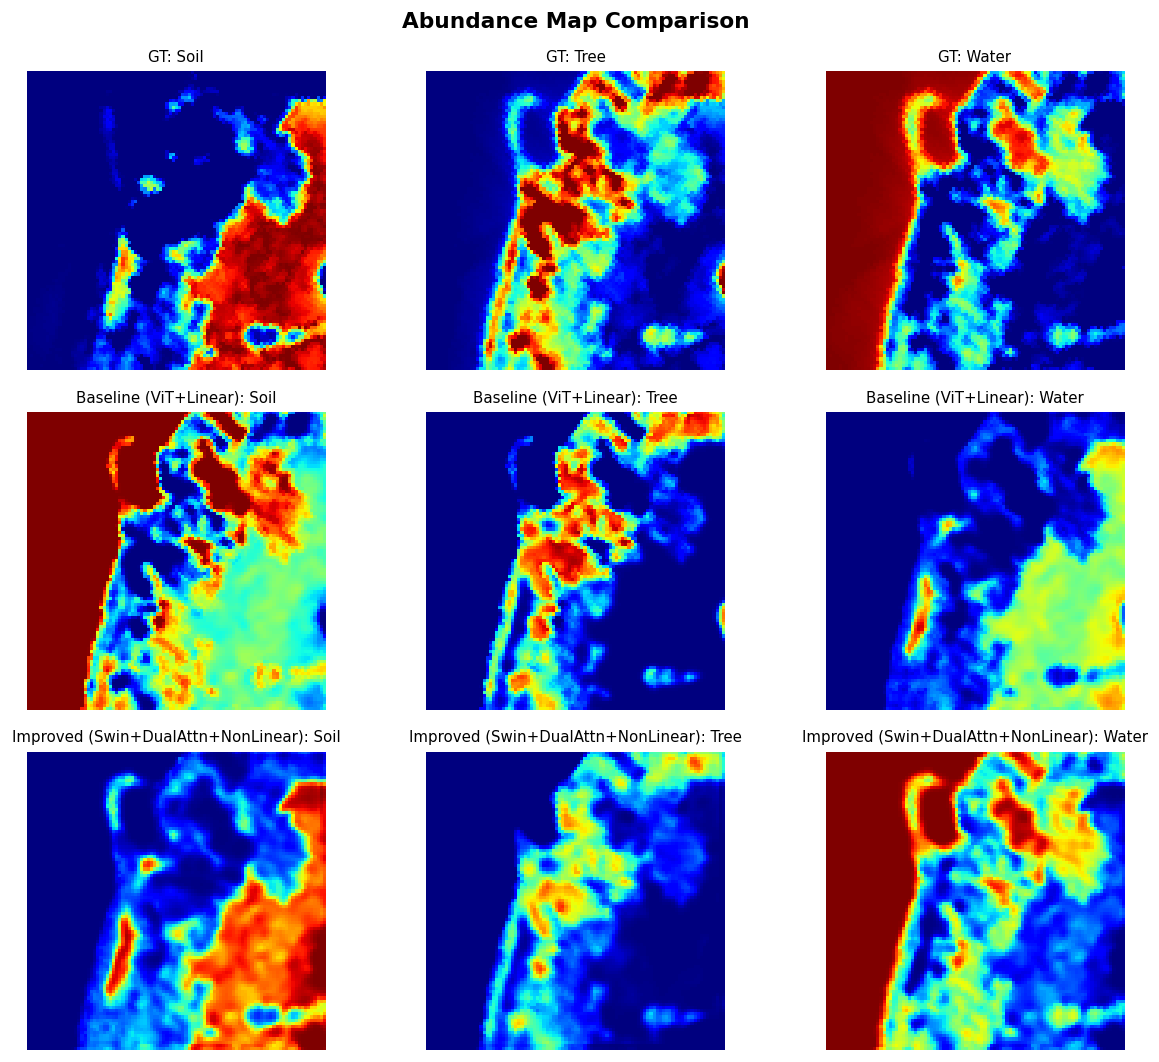

In [8]:
# All models vs GT in one figure
fig = plot_abundances_comparison(
    runs, labels, A_gt,
    endmember_names=ENDMEMBER_NAMES,
)
plt.show()

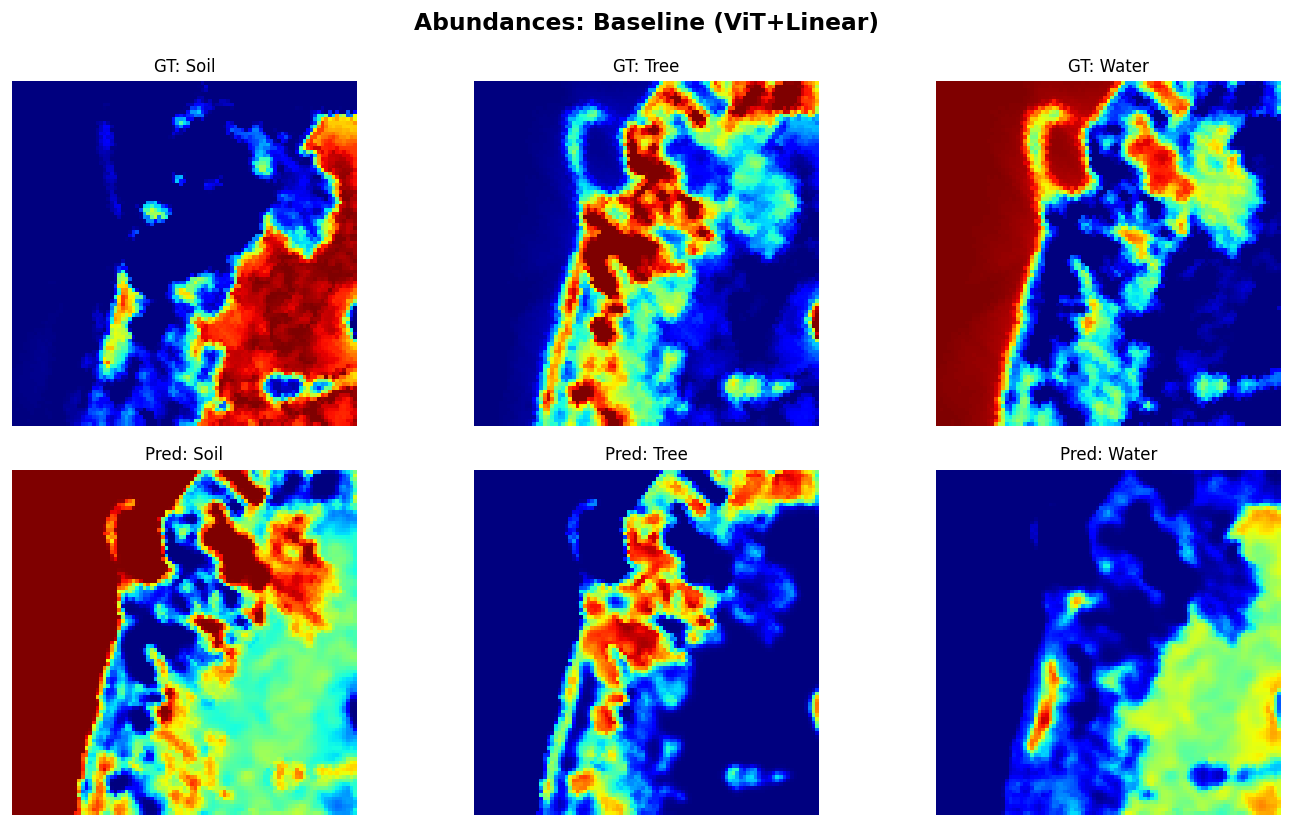

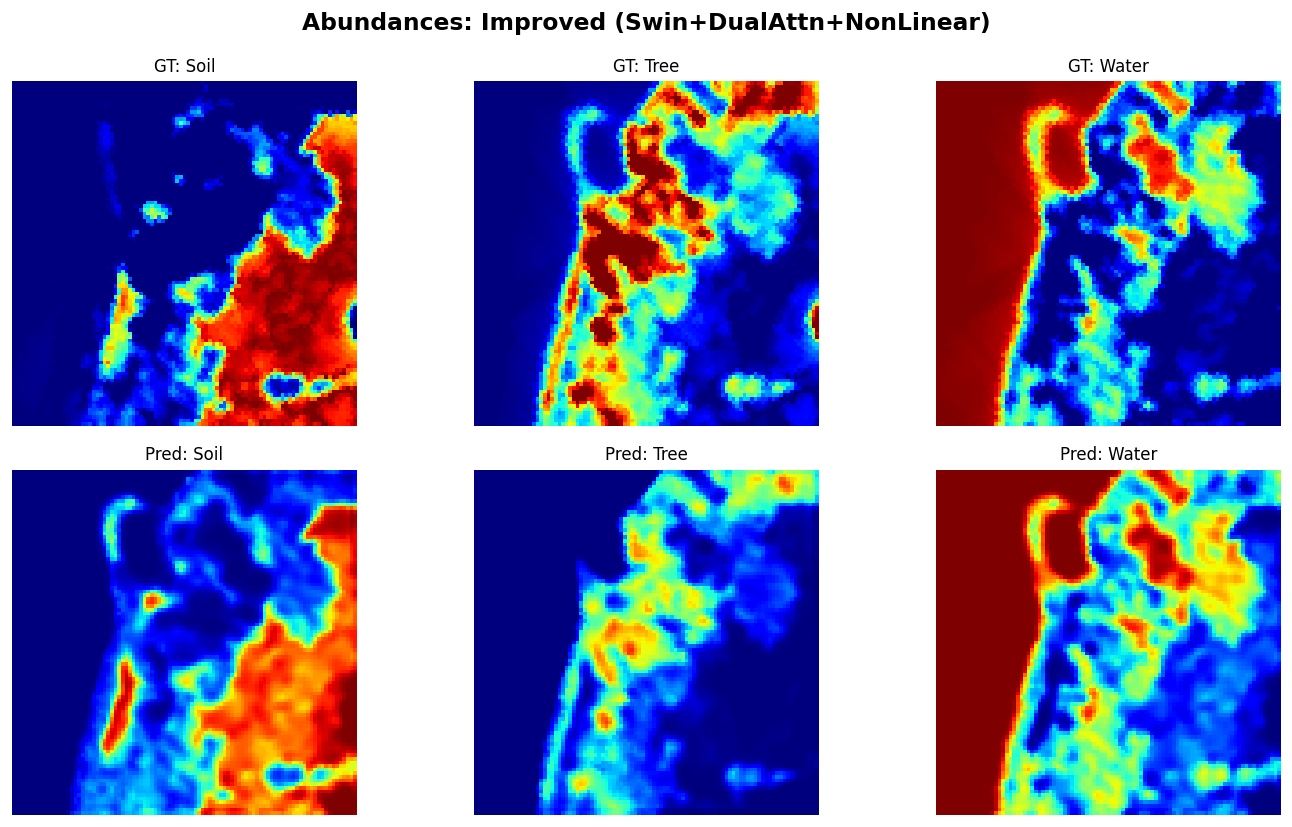

In [9]:
# Individual abundance maps per model
for run, lbl in zip(runs, labels):
    fig = plot_abundances(
        run['abu_est'], A_gt,
        endmember_names=ENDMEMBER_NAMES,
        title=f'Abundances: {lbl}',
    )
    plt.show()

## 7. Summary

| Aspect | Baseline (ViT) | Improved (Swin) |
|--------|---------------|------------------|
| Encoder | CNN + ViT (Cross-Attention) | CNN + DualAttention + Swin (Window Attention) |
| Decoder | Linear (LMM) | Non-linear (PPNMM bilinear) |
| Init | SiVM | SiVM |
| Complexity | O(N^2) | O(N * ws^2) |

**Note:** Run with more epochs (200+) for meaningful comparison. The 3-epoch test runs above only verify that the pipeline works end-to-end.